In [1]:
import sys
sys.path.insert(0, '../')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from ydata_profiling import ProfileReport
import io
import tabulate
import helpers_eda_inicial

/Users/solcalloni/Documents/github/modelos-para-prediccion-de-abandono/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/solcalloni/Documents/github/modelos-para-prediccion-de-abandono/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
personas = pd.read_csv('../../../assets/bronze/FCEN/FCEN_oficial_2005_2025/reporte_personas_desde_2005.csv')

In [3]:
actas = pd.read_csv('../../../assets/bronze/FCEN/FCEN_oficial_2005_2025/reporte_actas_desde_2005.csv', encoding='latin-1', dtype={'dni': str})

In [4]:
print('Personas:')
print(personas.shape)
print(personas.columns.tolist())

Personas:
(20173, 21)
['dni', 'edad', 'sexo', 'nacionalidad', 'codigo_postal', 'localidad', 'departamento', 'provincia', 'pais', 'dominio_email', 'carrera_principal', 'nivel_estudio', 'estado_nivel_estudio', 'situacion_padre', 'situacion_madre', 'nivel_estudio_padre', 'nivel_estudio_madre', 'acceso_a_internet', 'tiene_beca', 'situacion_laboral', 'año_inscripcion_facultad']


In [6]:
print('Actas:')
print(actas.shape)
print(actas.columns.tolist())

Actas:
(489810, 7)
['dni', 'materia', 'carrera', 'tipo_acta', 'fecha', 'nota', 'resultado']


DataFrame Report for df

The DataFrame has 20173 rows and 21 columns.
Below you will find detailed information about the DataFrame, including column data types,
summary statistics for both numerical and categorical data, missing values information,
and additional metrics that help understand the structure and quality of the dataset.

### General Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20173 entries, 0 to 20172
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   dni                       20173 non-null  object
 1   edad                      20173 non-null  int64 
 2   sexo                      20173 non-null  object
 3   nacionalidad              20173 non-null  object
 4   codigo_postal             13967 non-null  object
 5   localidad                 13952 non-null  object
 6   departamento              13952 non-null  object
 7   provincia                 13952 non-null

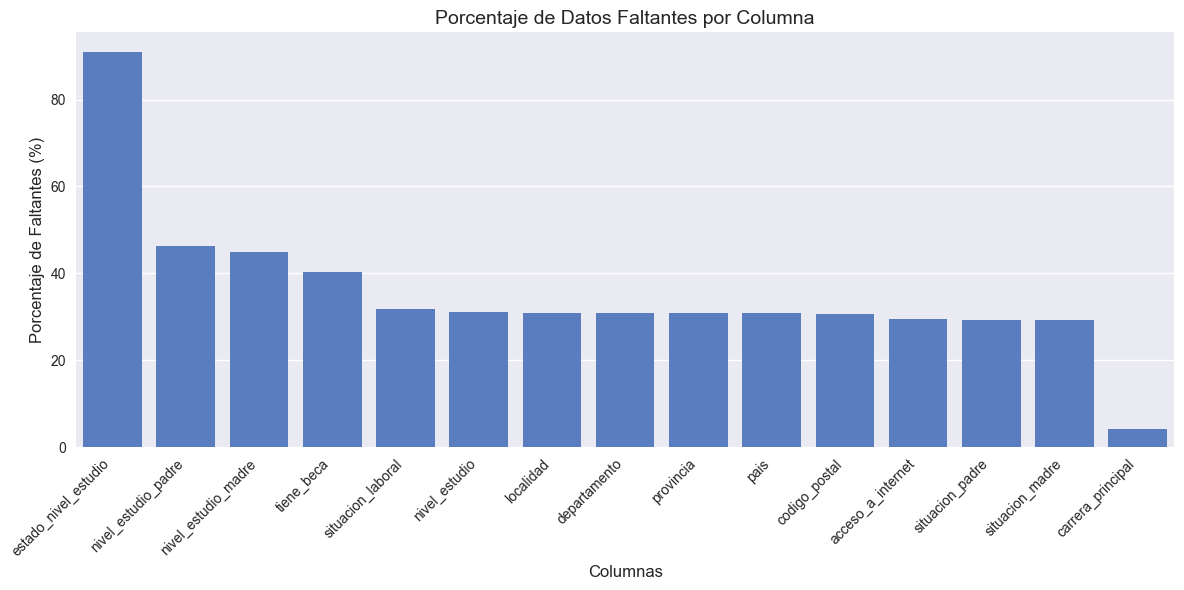


Columnas numéricas identificadas para análisis de outliers: ['edad', 'año_inscripcion_facultad']

=== Análisis de Valores Atípicos ===
--------------------------------------------------
Analizando 2 columnas numéricas.

--- Variable: edad ---
Q1: 24.00, Q3: 35.00, IQR: 11.00
Límite inferior: 7.50, Límite superior: 51.50
Número de valores atípicos: 210
Porcentaje de valores atípicos: 1.04%
Interpretación: Moderada presencia de outliers (1.04%). Considerar su impacto en modelos predictivos.


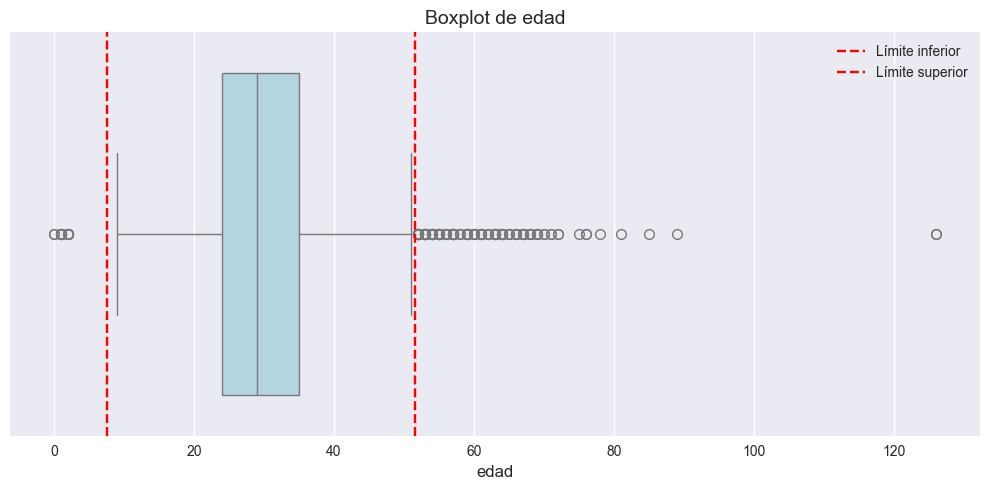


--- Variable: año_inscripcion_facultad ---
Q1: 2012.00, Q3: 2022.00, IQR: 10.00
Límite inferior: 1997.00, Límite superior: 2037.00
Número de valores atípicos: 0
Porcentaje de valores atípicos: 0.00%
Interpretación: Baja presencia de outliers (0.00%). Probablemente no afecten significativamente.


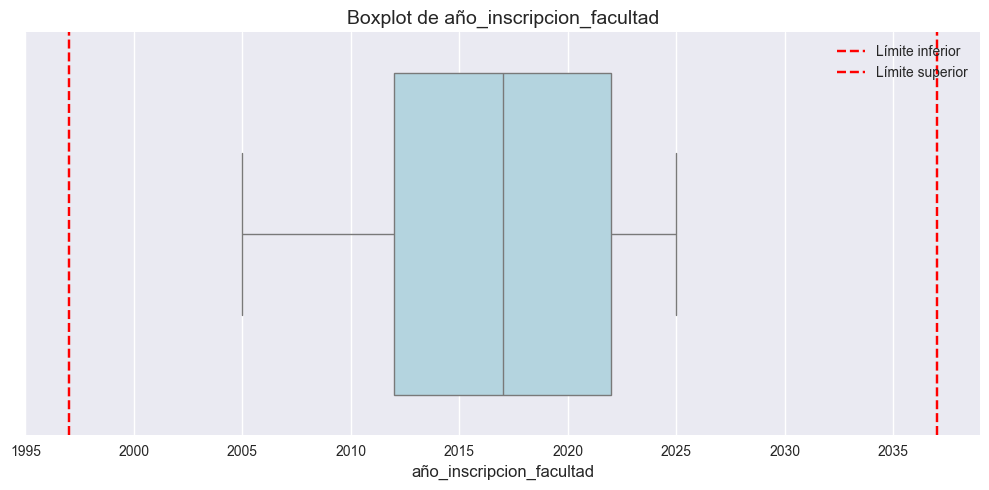


=== Fin del Análisis ===


In [7]:
helpers_eda_inicial.initial_eda(personas)

Para el primer análisis que vamos a realizar, vamos a trabajar con el DNI, el año de inscripción y la carrera principal. Sin embargo, puede que recalculemos la columna “carrera principal”. Notamos que hay un 4.16% de casos donde no tenemos la carrera principal, debemos revisar estos casos.
Todas las filas tienen DNI distintos.
No hay filas duplicadas
Los valores únicos en año de inscripción son válidos

In [8]:
personas['año_inscripcion_facultad'].unique()

array([2012, 2010, 2005, 2011, 2008, 2007, 2006, 2009, 2025, 2021, 2023,
       2020, 2013, 2024, 2014, 2015, 2016, 2017, 2018, 2022, 2019])

DataFrame Report for df

The DataFrame has 489810 rows and 7 columns.
Below you will find detailed information about the DataFrame, including column data types,
summary statistics for both numerical and categorical data, missing values information,
and additional metrics that help understand the structure and quality of the dataset.

### General Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 489810 entries, 0 to 489809
Data columns (total 7 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   dni        489810 non-null  object
 1   materia    489810 non-null  object
 2   carrera    489810 non-null  object
 3   tipo_acta  489810 non-null  object
 4   fecha      489810 non-null  object
 5   nota       441017 non-null  object
 6   resultado  489810 non-null  object
dtypes: object(7)
memory usage: 26.2+ MB


### Data Types
This table lists the data type for each column, which is helpful in determining appropriate data cleaning and pr

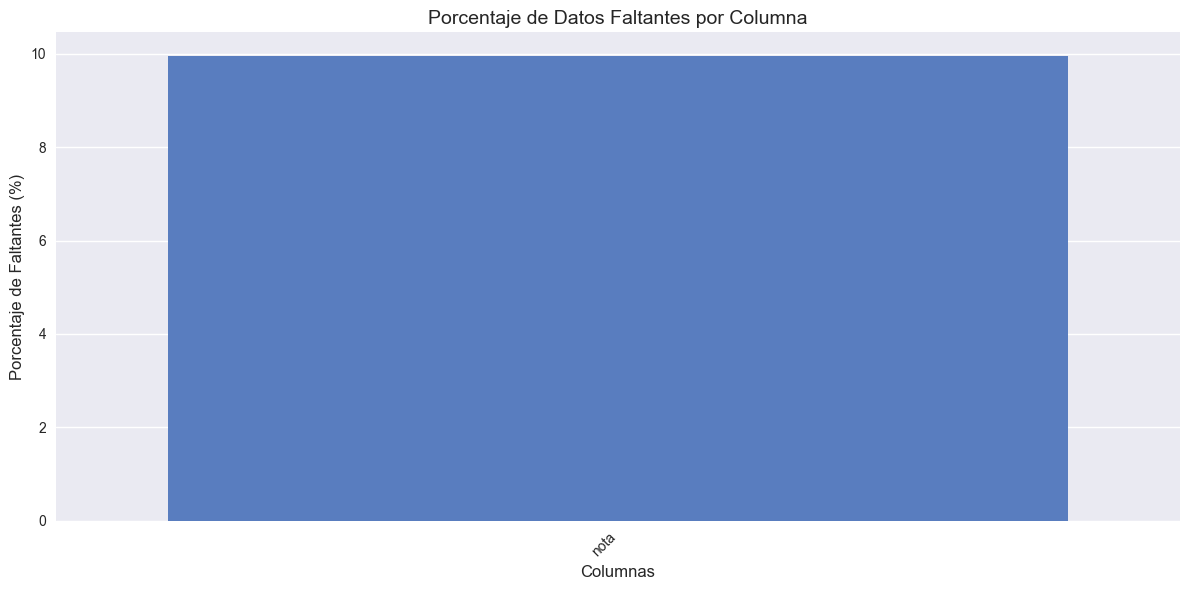


Columnas numéricas identificadas para análisis de outliers: []

=== Análisis de Valores Atípicos ===
--------------------------------------------------
Analizando 0 columnas numéricas.

=== Fin del Análisis ===


In [9]:
helpers_eda_inicial.initial_eda(actas)

In [10]:
actas['resultado'].unique()

array(['Aprobado', 'Reprobado', 'Ausente'], dtype=object)

Vemos que tenemos menos DNIs en actas que en los datos de personas (19333 vs 20173)
Hay un 9% de notas faltantes pero tenemos “resultado” y “tipo_acta”. Ademas, no hay datos faltantes en materia, carrera o fecha
Es correcto que tipo_acta tenga solo 2 valores posibles. Además sabemos que resultado es ‘Aprobado', 'Reprobado', 'Ausente' (en ese caso la columna nota no tiene valor)

## Revisamos los DNIs

In [12]:
personas['dni'] = personas['dni'].astype(str)
# Largo de cada string
personas['longitud'] = personas['dni'].str.len()
# Estadísticas descriptivas
print(personas['longitud'].describe())

count    20173.000000
mean         8.000347
std          0.043969
min          7.000000
25%          8.000000
50%          8.000000
75%          8.000000
max         11.000000
Name: longitud, dtype: float64


In [13]:
personas['longitud'].value_counts()

longitud
8     20158
7         7
9         5
11        3
Name: count, dtype: int64

In [14]:
# veo cuantos dni de actas coinciden con los de personas
actas_dni = set(actas['dni'])
personas_dni = set(personas['dni'])
print(f'Cantidad de dni en actas: {len(actas_dni)}')
print(f'Cantidad de dni en personas: {len(personas_dni)}')
print(f'Cantidad de dni en actas que coinciden con personas: {len(actas_dni.intersection(personas_dni))}')

Cantidad de dni en actas: 19333
Cantidad de dni en personas: 20173
Cantidad de dni en actas que coinciden con personas: 19333


Ahora que corregimos los tipos de datos vemos que todos los DNI que figuran en actas se encuentran en los datos de personas. Podemos revisar si notamos algo particular de los DNI de personas que no estan en actas, suponemos que se debe a que nunca se inscribieron a materias.

Vemos que 840 no tienen refinida carrera principal, lo cual coincide con la hipótesis de que nunca se inscribieron a una materia.

In [15]:
personas[~personas['dni'].isin(actas['dni'])]['carrera_principal'].value_counts(dropna=False)

carrera_principal
NaN    840
Name: count, dtype: int64

## Revisamos el campo de carrera

In [20]:
personas['carrera_principal'].value_counts(dropna=False)

carrera_principal
Licenciatura en Ciencias Biológicas                                                    5369
Licenciatura en Ciencias de la Computación                                             3927
Licenciatura en Ciencias Físicas                                                       2796
Licenciatura en Ciencias Químicas                                                      1508
Licenciatura en Ciencias Matemáticas                                                   1254
Licenciatura en Ciencias de Datos                                                      1120
Licenciatura en Ciencias Geológicas                                                     871
NaN                                                                                     840
Materias de Otras Carreras                                                              595
Licenciatura en Ciencias de la Atmósfera                                                498
Licenciatura en Ciencia y Tecnología de Alimentos             

In [21]:
actas['carrera'].value_counts(dropna=False)

carrera
Licenciatura en Ciencias Biológicas                                                    127999
Licenciatura en Ciencias de la Computación                                              81130
Licenciatura en Ciencias Físicas                                                        74285
Licenciatura en Ciencias Químicas                                                       38308
Materias de Otras Carreras                                                              33779
Licenciatura en Ciencias Geológicas                                                     32941
Licenciatura en Ciencias Matemáticas                                                    27240
Licenciatura en Ciencias de Datos                                                       15723
Doctorado de la Universidad de Buenos Aires                                             13152
Licenciatura en Ciencias de la Atmósfera                                                10937
Licenciatura en Ciencia y Tecnología de Alimentos   

In [24]:
actas['materia'].nunique()

2092

Habrá carreras que no van a aparecer más cuando hagamos el filtro para identificar las materias de cada una de las carreras. No nos deberíamos quedar con materias que sean de postgrado, doctorado o especializaciones.